## Solving 3D quantum harmonic oscillator

We'll use Numerov algorithm to solve the ODE associated to the problem.

In [2]:
import matplotlib.pyplot as plt
import numpy as np

In [132]:
def k(r, l, E):
    """Calculate the k(x) function for the Schrödinger equation."""
    if r != 0:
        return 2 * (E - 0.5 * r**2 - 0.5 * l*(l+1)/(r*r))
    else:
        return 1
    
def isin_classical_region(r, l, E):
    return k(r, l, E) > 0

def numerov_step(psi_prev, psi_curr, k_prev, k_curr, h):
    """Perform a single step of the Numerov method."""
    return (2 * (1 - (5 * h**2 * k_curr / 12)) * psi_curr - (1 + (h**2 * k_prev / 12)) * psi_prev) / (1 + (h**2 * k_curr / 12))

def integration(E, r_min, r_max, h, l, psi_0_outward, psi_1_outward, psi_0_inward, psi_1_inward):

    if isin_classical_region(r_max, l, E):
        # not good, r_max must be after the classical turning point
        print("r_max too small")
        return

    # outward integration (classical region)
    # boundary conditions are known by the problem
    r = r_min
    # create list representing the wave function's values
    psi_outward = []
    psi_outward.append(psi_0_outward)
    psi_outward.append(psi_1_outward)
    # create list representing the wave function's coordinates
    coord_outward = []
    coord_outward.append(r)
    coord_outward.append(r+h)

    # buffer (to keep the matching in the classical region)
    buffer = 5*h

    # outward integration
    while isin_classical_region(r+buffer, l, E):
        k_prev = k(r, l, E)
        k_curr = k(r+h, l, E)
        temp = numerov_step(psi_0_outward, psi_1_outward, k_prev, k_curr, h)
        psi_outward.append(temp)
        psi_0_outward = psi_1_outward
        psi_1_outward = temp
        r += h
        coord_outward.append(r+h)

    # inward integration (non-classical region)
    # boundary conditions are known either by the specific problem or by using WKB approximation
    r = r_max 
    # create list representing the wave function's values
    psi_inward= []
    psi_inward.append(psi_0_inward)
    psi_inward.append(psi_1_inward)
    # create list representing the wave function's coordinates
    coord_inward = []
    coord_inward.append(r)
    coord_inward.append(r-h)

    # inward integration
    while not isin_classical_region(r-buffer, l, E):
        k_prev = k(r, l, E)
        k_curr = k(r+h, l, E)
        temp = numerov_step(psi_0_inward, psi_1_inward, k_prev, k_curr, h)
        psi_inward.append(temp)
        psi_0_inward = psi_1_inward
        psi_1_inward = temp
        r -= h
        coord_inward.append(r-h)

    # reverse lists for inward integration
    coord_inward = coord_inward[::-1]
    psi_inward = np.array(psi_inward[::-1])*psi_outward[-1:]/max(psi_inward)

    # log matching
    temp = psi_outward[::-1]
    F_outward = (temp[0] - temp[2])/(2*h*temp[1])
    F_inward = (psi_inward[2] - psi_inward[0])/(2*h*psi_inward[1])

    # numpize and merge solution
    psi = np.concat((psi_outward, psi_inward))
    coord = np.concat((coord_outward, coord_inward))

    return (coord, psi, F_outward-F_inward)


In [137]:
l = 0
h = .001
r_min = 0
r_max = 10
E = (3.5)/2

psi_1_inward = np.sqrt(k(r_max, l, E)/k(r_max-h,l,E))*np.exp(h/2*(k(r_max, l, E)-k(r_max-h,l,E)))

coord, psi, error = integration(E, r_min, r_max, h, l, 0, np.pow(h, l+1), 1, psi_1_inward)


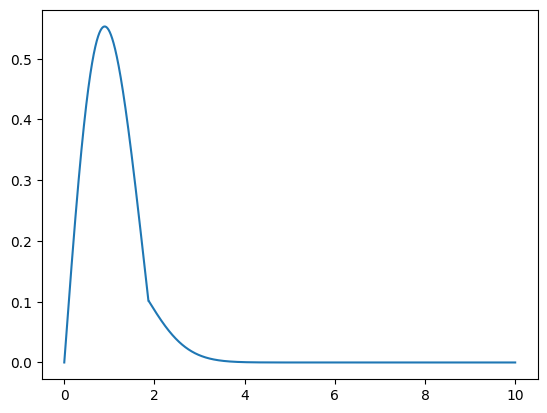

In [138]:
plt.plot(coord,psi)

In [128]:
error

np.float64(-5.325680403825239)

In [86]:
a = [1,2,3,4,5]

In [131]:
a[-1:]

[5]